In [34]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from analysis.sta_analysis import compute_explained_variance

In [35]:
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

## Load data

In [36]:
neural_data_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/MergedITCells_500Stim_AxisTuned.mat')

with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

In [37]:
alexnet_fc6_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents/val_latents.npy"))
sdvae_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_sd_vae_latents/val_latents_64x64.npy"))
clip_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_l14_pca_latents/val_latents.npy"))

In [52]:
# # SD VAE latents: spatial (4, 64, 64), flattened here for axis-tuning/regression and
# # unflattened again when saving regressed_latents_64x64.npy below.
# REGRESSION_OUTPUT_DIR = os.path.join(REPO_ROOT, "data/stimuli_sd_vae_latents")
# NATIVE_LATENT_SHAPE = sdvae_latents.shape[1:]  # (4, 64, 64)
# stimuli_embeddings = sdvae_latents.reshape(sdvae_latents.shape[0], -1)  # (500, 16384)

# CLIP ViT-L/14 embeddings: already flat.
REGRESSION_OUTPUT_DIR = os.path.join(REPO_ROOT, "data/stimuli_clip_vit_l14_pca_latents")
NATIVE_LATENT_SHAPE = clip_latents.shape[1:]  # (768,)
stimuli_embeddings = clip_latents

# # AlexNet fc6 latents: already flat
# REGRESSION_OUTPUT_DIR = os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents")
# NATIVE_LATENT_SHAPE = alexnet_fc6_latents.shape[1:]  # (768,)
# stimuli_embeddings = alexnet_fc6_latents

## Ridge regression

In [53]:
def evaluate(y_pred, label):
    dim_ev = np.array([compute_explained_variance(y_test[:, d], y_pred[:, d]) for d in range(y_test.shape[1])])
    overall_ev = compute_explained_variance(y_test.flatten(), y_pred.flatten())
    print(f"{label}: held-out EV (flattened):={overall_ev:.3f}") 
    print(f"Per-dimension EV: mean={dim_ev.mean():.3f}, median={np.median(dim_ev):.3f}") 
    print(f"Dimensions with EV > 0.1: {int((dim_ev>0.1).sum())}/{len(dim_ev)}")
    return dim_ev

In [54]:
# Train/test split over the 500 stimuli
rng = np.random.default_rng(0)
n_stim = neural_matrix.shape[1]
perm = rng.permutation(n_stim)
n_test = int(0.2 * n_stim)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, X_test = neural_matrix[:, train_idx].T, neural_matrix[:, test_idx].T  # (n_stim, 386 neurons)
y_train, y_test = stimuli_embeddings[train_idx], stimuli_embeddings[test_idx]  # (n_stim, n_features), flattened

In [55]:
# standardize, then PCA the neural features down before regressing -- n_train (400) and
# p_features (386) are close enough that raw Ridge sees a near-collinear, poorly
# conditioned design matrix; PCA gives it fewer, decorrelated directions to regularize over
N_NEURAL_PCA_COMPONENTS = 100  # tune against the explained-variance printout below

scaler = StandardScaler().fit(X_train)
Xtr_scaled, Xte_scaled = scaler.transform(X_train), scaler.transform(X_test)

neural_pca = PCA(n_components=N_NEURAL_PCA_COMPONENTS, random_state=0).fit(Xtr_scaled)
Xtr_s, Xte_s = neural_pca.transform(Xtr_scaled), neural_pca.transform(Xte_scaled)

print(f"Neural PCA: {X_train.shape[1]} neurons -> {N_NEURAL_PCA_COMPONENTS} components "
      f"(explained variance retained: {neural_pca.explained_variance_ratio_.sum():.3f})")

Neural PCA: 386 neurons -> 100 components (explained variance retained: 0.767)


In [56]:
# cross-validated alpha per target dimension, now on the PCA'd neural features
rcv = RidgeCV(alphas=np.logspace(-1, 6, 30), alpha_per_target=True).fit(Xtr_s, y_train)
y_pred = rcv.predict(Xte_s)
dim_ev = evaluate(y_pred, "PCA + scaled RidgeCV (alpha_per_target)")
print("chosen alphas range:", rcv.alpha_.min(), rcv.alpha_.max())

PCA + scaled RidgeCV (alpha_per_target): held-out EV (flattened):=0.666
Per-dimension EV: mean=0.122, median=0.107
Dimensions with EV > 0.1: 399/768
chosen alphas range: 417.53189365604044 11721.022975334818


In [57]:
y_fit = rcv.predict(Xtr_s)

In [58]:
# Scatter y_fit (predicts stimuli_embeddings[train_idx]) / y_pred (predicts
# stimuli_embeddings[test_idx]) back into one (n_stim, *NATIVE_LATENT_SHAPE) array in
# original stimulus order -- train_idx/test_idx are a random permutation (see the
# train/test split cell above), so this undoes that shuffle: row i here matches row i
# of the source val_latents(_64x64).npy file this regression's target came from.
n_stim = neural_matrix.shape[1]
regressed_latents = np.empty((n_stim, *NATIVE_LATENT_SHAPE), dtype=np.float32)
regressed_latents[train_idx] = y_fit.reshape(-1, *NATIVE_LATENT_SHAPE)
regressed_latents[test_idx] = y_pred.reshape(-1, *NATIVE_LATENT_SHAPE)

regressed_latents_path = os.path.join(REGRESSION_OUTPUT_DIR, "regressed_latents_64x64.npy")
np.save(regressed_latents_path, regressed_latents)
print(f"Saved regressed latents {regressed_latents.shape} (original stimulus order) to {regressed_latents_path}")

Saved regressed latents (500, 768) (original stimulus order) to /home/jhanliufu/RutishauserLab/DiffusionBANMap/data/stimuli_clip_vit_l14_pca_latents/regressed_latents_64x64.npy


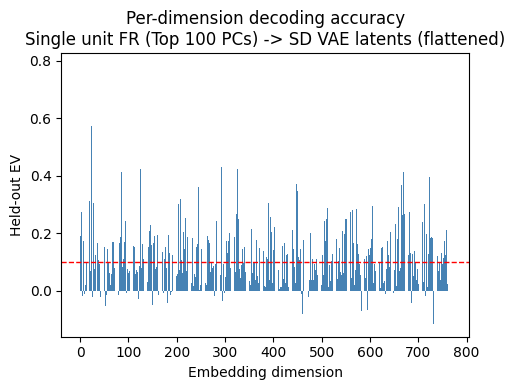

In [59]:
plt.figure(figsize=(5, 4))
plt.bar(np.arange(len(dim_ev)), dim_ev, color='steelblue')
plt.axhline(0.1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Embedding dimension')
plt.ylabel('Held-out EV')
plt.title('Per-dimension decoding accuracy\nSingle unit FR (Top 100 PCs) -> SD VAE latents (flattened)')
plt.tight_layout()
plt.show()

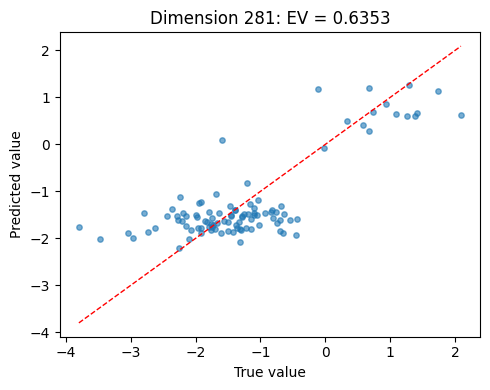

In [60]:
example_dim = 281
plt.figure(figsize=(5, 4))
plt.scatter(y_test[:, example_dim], y_pred[:, example_dim], alpha=0.6, s=15)
lims = [min(y_test[:, example_dim].min(), y_pred[:, example_dim].min()), max(y_test[:, example_dim].max(), y_pred[:, example_dim].max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel(f'True value')
plt.ylabel(f'Predicted value')
plt.title(f'Dimension {example_dim}: EV = {dim_ev[example_dim]:.4f}')
plt.tight_layout()
plt.show()

## PCA-reduced latent regression

Instead of regressing neural PCs directly onto the (flattened) latent embedding, reduce
the latent embeddings to a low-dimensional PCA space first, regress neural PCs onto
*latent* PCs, then project the regressed latent PCs back to the original embedding
space. Compare per-dimension held-out EV against the direct regression above.

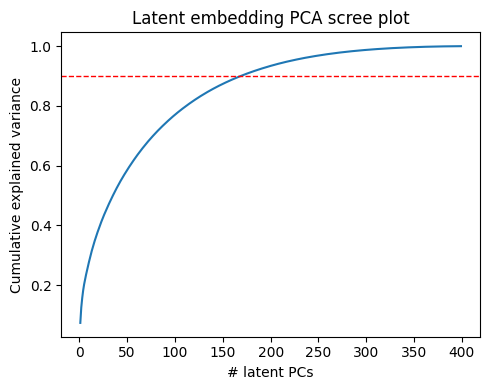

In [61]:
# How many latent PCs are needed to capture most of the variance? Fit on the
# standardized *training* latents only (no test leakage) and inspect the scree plot
# before committing to N_LATENT_PCA_COMPONENTS below.
latent_scaler = StandardScaler().fit(y_train)
ytr_scaled, yte_scaled = latent_scaler.transform(y_train), latent_scaler.transform(y_test)

max_latent_components = min(X_train.shape[0] - 1, y_train.shape[1])
latent_pca_full = PCA(n_components=max_latent_components, random_state=0).fit(ytr_scaled)
cum_ev = np.cumsum(latent_pca_full.explained_variance_ratio_)

plt.figure(figsize=(5, 4))
plt.plot(np.arange(1, len(cum_ev) + 1), cum_ev)
plt.axhline(0.9, color='red', linestyle='--', linewidth=1)
plt.xlabel('# latent PCs')
plt.ylabel('Cumulative explained variance')
plt.title('Latent embedding PCA scree plot')
plt.tight_layout()
plt.show()

In [62]:
N_LATENT_PCA_COMPONENTS = 150  # tune against the scree plot above

latent_pca = PCA(n_components=N_LATENT_PCA_COMPONENTS, random_state=0).fit(ytr_scaled)
ytr_pcs, yte_pcs = latent_pca.transform(ytr_scaled), latent_pca.transform(yte_scaled)

print(f"Latent PCA: {y_train.shape[1]} dims -> {N_LATENT_PCA_COMPONENTS} components "
      f"(explained variance retained: {latent_pca.explained_variance_ratio_.sum():.3f})")

Latent PCA: 768 dims -> 150 components (explained variance retained: 0.872)


In [63]:
# Regress from the same neural PCs used above (Xtr_s / Xte_s), but onto latent PCs
# instead of the raw (flattened) latent dimensions
rcv_pcs = RidgeCV(alphas=np.logspace(-1, 6, 30), alpha_per_target=True).fit(Xtr_s, ytr_pcs)
ytr_pcs_pred, yte_pcs_pred = rcv_pcs.predict(Xtr_s), rcv_pcs.predict(Xte_s)

# Project regressed latent PCs back to the original (flattened) latent space
y_fit_pca_route = latent_scaler.inverse_transform(latent_pca.inverse_transform(ytr_pcs_pred))
y_pred_pca_route = latent_scaler.inverse_transform(latent_pca.inverse_transform(yte_pcs_pred))

In [64]:
dim_ev_pca_route = evaluate(y_pred_pca_route, "PCA + scaled RidgeCV (neural PCs -> latent PCs -> inverse PCA)")

PCA + scaled RidgeCV (neural PCs -> latent PCs -> inverse PCA): held-out EV (flattened):=0.668
Per-dimension EV: mean=0.125, median=0.111
Dimensions with EV > 0.1: 425/768


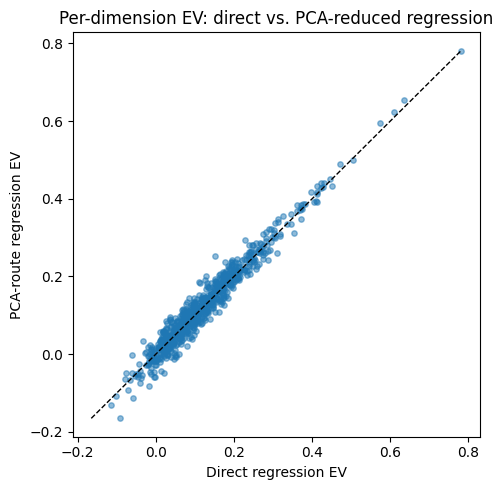

Direct regression:    mean EV=0.122, dims>0.1=399/768
PCA-route regression: mean EV=0.125, dims>0.1=425/768


In [65]:
plt.figure(figsize=(5, 5))
plt.scatter(dim_ev, dim_ev_pca_route, alpha=0.5, s=15)
lims = [min(dim_ev.min(), dim_ev_pca_route.min()), max(dim_ev.max(), dim_ev_pca_route.max())]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlabel('Direct regression EV')
plt.ylabel('PCA-route regression EV')
plt.title('Per-dimension EV: direct vs. PCA-reduced regression')
plt.tight_layout()
plt.show()

print(f"Direct regression:    mean EV={dim_ev.mean():.3f}, dims>0.1={(dim_ev>0.1).sum()}/{len(dim_ev)}")
print(f"PCA-route regression: mean EV={dim_ev_pca_route.mean():.3f}, dims>0.1={(dim_ev_pca_route>0.1).sum()}/{len(dim_ev_pca_route)}")